# DHMoE: Diffusion Generated Hierarchical Multi-Granular Expertise

Implementation based on: *DHMoE: Diffusion Generated Hierarchical Multi-Granular Expertise for Stock Prediction* (Chen & Wang, AAAI 2025)

**Key Idea:** Use diffusion as a *hypernetwork* — the Diffusion Inverted Transformer (DIT) generates robust features from noisy data, which are then used to dynamically generate weights for a tree of experts.

**Architecture (3-layer tree):**
1. **Root — DIT**: Conditional DDPM with iTransformer backbone. Processes noised time series conditioned on multimodal info. Denoised output → MLP → parameters for middle experts.
2. **Middle Experts**: Modulate root parameters with own learnable pool, distribute to bottom experts.
3. **Bottom Experts**: FourierMLP with *dynamically generated weights*. Each processes a specific modality.
4. **SSAM**: Sparse Synthesized Attention aggregates predictions bottom→middle→top.

**Generalized** for any entity-level time series (stations, stocks, sensors). Uses random tensors as demo.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
from torch.utils.data import Dataset, DataLoader

## Configuration

In [19]:
class DHMoEConfig:
    # Data dimensions
    num_entities = 50          # N (stocks / stations)
    lookback = 16              # T timesteps
    num_features = 5           # D features per entity per timestep
    num_graph_types = 2        # S types of relational graphs
    num_sgc_hops = 2           # hops for SGC graph embedding

    # DIT (Diffusion Inverted Transformer)
    d_model = 64               # hidden dimension
    n_heads = 4
    n_blocks = 4               # Z iTransformer blocks
    d_ff = 256                 # feed-forward inner dim
    dropout = 0.1

    # Hierarchical MoE
    num_middle_experts = 3     # a
    num_bottom_experts = 3     # b per middle expert (total a*b)
    expert_hidden = 20         # F hidden dim in FourierMLP
    fourier_features = 16      # Fourier projection dim
    num_modalities = 3         # time series, graph, auxiliary

    # Diffusion schedule (quadratic, Eq. in paper)
    diffusion_steps = 100      # K
    beta_1 = 0.0001            # minimum noise
    beta_K = 0.2               # maximum noise

    # Loss weights
    alpha_cond = 4.0           # weight for diffusion loss

    # Training
    lr = 1e-3
    batch_size = 4
    epochs = 100

config = DHMoEConfig()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Entities: {config.num_entities}, Lookback: {config.lookback}, Features: {config.num_features}')
print(f'Middle experts: {config.num_middle_experts}, Bottom per middle: {config.num_bottom_experts}')
print(f'Total bottom experts: {config.num_middle_experts * config.num_bottom_experts}')

Device: cuda
Entities: 50, Lookback: 16, Features: 5
Middle experts: 3, Bottom per middle: 3
Total bottom experts: 9


## Generate Random Data & Relational Graphs

Replace with real data for actual use. Graphs encode entity relations (e.g. industry/sector, geographic proximity).

In [20]:
def generate_random_data(config, num_samples=500, seed=42):
    rng = np.random.default_rng(seed)
    N, T, D = config.num_entities, config.lookback, config.num_features

    X = rng.standard_normal((num_samples, N, T, D)).astype(np.float32)
    Y = rng.standard_normal((num_samples, N)).astype(np.float32)  # one target per entity

    # S relational graphs (sparse random adjacency)
    A_list = []
    for _ in range(config.num_graph_types):
        A = rng.uniform(0, 1, (N, N)).astype(np.float32)
        A = np.where(A > 0.7, A, 0)  # sparsify
        np.fill_diagonal(A, 0)
        # Symmetric normalize
        A_tilde = A + np.eye(N, dtype=np.float32)
        D_inv = np.diag(A_tilde.sum(1) ** -0.5)
        A_norm = D_inv @ A_tilde @ D_inv
        A_list.append(A_norm.astype(np.float32))

    return X, Y, A_list


X_all, Y_all, A_list_np = generate_random_data(config)

n = len(X_all)
n_train, n_val = int(0.7 * n), int(0.1 * n)
X_train, Y_train = X_all[:n_train], Y_all[:n_train]
X_val, Y_val = X_all[n_train:n_train+n_val], Y_all[n_train:n_train+n_val]
X_test, Y_test = X_all[n_train+n_val:], Y_all[n_train+n_val:]

A_tensors = [torch.tensor(A, device=device) for A in A_list_np]

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Target shape: {Y_train.shape} (one value per entity)')
print(f'Graphs: {len(A_tensors)} x ({A_tensors[0].shape})')

Train: (350, 50, 16, 5), Val: (50, 50, 16, 5), Test: (100, 50, 16, 5)
Target shape: (350, 50) (one value per entity)
Graphs: 2 x (torch.Size([50, 50]))


In [21]:
class EntityTimeSeriesDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


train_loader = DataLoader(EntityTimeSeriesDataset(X_train, Y_train),
                          batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(EntityTimeSeriesDataset(X_val, Y_val),
                        batch_size=config.batch_size)
test_loader = DataLoader(EntityTimeSeriesDataset(X_test, Y_test),
                         batch_size=config.batch_size)

## Sparsemax (Martins & Astudillo, 2016)

Projects onto the probability simplex — produces genuinely sparse attention weights, unlike softmax which only approaches zero.

In [22]:
def sparsemax(z, dim=-1):
    z_sorted, _ = z.sort(dim=dim, descending=True)
    z_cumsum = z_sorted.cumsum(dim=dim)
    k = torch.arange(1, z.size(dim) + 1, device=z.device, dtype=z.dtype)
    shape = [1] * z.dim()
    shape[dim] = -1
    k = k.view(shape)
    support = (1 + k * z_sorted > z_cumsum).float()
    k_max = support.sum(dim=dim, keepdim=True)
    tau_idx = (k_max - 1).long().clamp(min=0)
    tau = (z_cumsum.gather(dim, tau_idx) - 1) / k_max
    return torch.clamp(z - tau, min=0)

## SGC Graph Embedding (Eq. 7)

Simplified Graph Convolution (Wu et al., 2019): merges graph structure with time series by aggregating multi-hop neighborhoods across multiple relation types.

$$E_g = \sum_{k=1}^{K_{\text{hops}}} \sum_{i=1}^{S} (A_i)^k \, x^h \, W_{ik}$$

In [23]:
class SGCEmbedding(nn.Module):
    def __init__(self, num_graph_types, num_hops, input_dim, output_dim):
        super().__init__()
        self.num_hops = num_hops
        self.projections = nn.ModuleList([
            nn.ModuleList([
                nn.Linear(input_dim, output_dim, bias=False)
                for _ in range(num_hops)
            ])
            for _ in range(num_graph_types)
        ])

    def forward(self, x, A_list):
        """
        x:      (B, N, D_in)  flattened time series per entity
        A_list: list of S normalized adjacency matrices, each (N, N)
        Returns: (B, N, D_out)
        """
        result = 0
        for s, A in enumerate(A_list):
            A_pow = A
            for hop in range(self.num_hops):
                agg = A_pow @ x                          # (B, N, D_in)
                result = result + self.projections[s][hop](agg)
                if hop < self.num_hops - 1:
                    A_pow = A_pow @ A
        return result

## Diffusion Schedule & Step Embedding

Quadratic noise schedule from the paper:
$$\beta_k = \left(\frac{K-k}{K-1}\sqrt{\beta_1} + \frac{k-1}{K-1}\sqrt{\beta_K}\right)^2$$

In [24]:
def quadratic_beta_schedule(K, beta_1, beta_K):
    steps = torch.arange(1, K + 1, dtype=torch.float32)
    sqrt_beta = ((K - steps) / (K - 1)) * math.sqrt(beta_1) + \
                ((steps - 1) / (K - 1)) * math.sqrt(beta_K)
    return sqrt_beta ** 2


class SinusoidalStepEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4), nn.SiLU(), nn.Linear(dim * 4, dim),
        )

    def forward(self, k):
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000.0) * torch.arange(half, device=k.device, dtype=torch.float32) / half
        )
        emb = torch.cat([torch.sin(k.float().unsqueeze(-1) * freqs),
                         torch.cos(k.float().unsqueeze(-1) * freqs)], dim=-1)
        return self.mlp(emb)

## iTransformer Block (Eq. 8-10, Fig. 2)

The Inverted Transformer (Liu et al., 2024) treats each **entity** as a token (not each timestep). Attention runs over N entities, capturing inter-entity dependencies.

Each block fuses conditional information $C_i$ via `ConEmb` (Eq. 10):
$$E_o = \text{LayerNorm}\bigl(\text{FFN}(E_m) + \text{ConEmb}(C_i)\bigr)$$

In [25]:
class iTransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )
        self.cond_emb = nn.Linear(d_model, d_model)

    def forward(self, x, cond=None):
        """
        x:    (B, N, d_model)  entity tokens
        cond: (B, N, d_model)  conditional embedding (optional)
        """
        h = self.norm1(x)
        x = x + self.attn(h, h, h, need_weights=False)[0]
        ffn_out = self.ffn(self.norm2(x))
        if cond is not None:
            ffn_out = ffn_out + self.cond_emb(cond)
        return x + ffn_out

## Bottom Expert — FourierMLP with Generated Weights (Eq. 12)

A 3-layer MLP whose **weights are dynamically generated** by the parent middle expert (hypernetwork). Fourier features (Tancik et al., 2020) let it capture high-frequency patterns.

$$X_{\text{fou}} = a_f\,[\sin(2\pi X_{\text{in}} B_f) \| \cos(2\pi X_{\text{in}} B_f)]$$
$$O_{i,k} = \text{LU}(\text{LU}(\text{LU}(X_{\text{fou}} W_1 + b_1) W_2 + b_2) W_3 + b_3)$$

where $\{W_{1:3}, b_{1:3}\}$ are the *generated* parameters.

In [26]:
class BottomExpert(nn.Module):
    """FourierMLP with dynamically generated weights."""

    def __init__(self, input_dim, hidden_dim, fourier_features):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.fourier_dim = fourier_features * 2  # sin + cos

        # Fourier feature params (shared, NOT generated)
        self.B_f = nn.Parameter(torch.randn(input_dim, fourier_features) * 0.1)
        self.a_f = nn.Parameter(torch.ones(1))

        # Total count of generated parameters
        fd, h = self.fourier_dim, hidden_dim
        self.param_size = (fd * h + h) + (h * h + h) + (h * 1 + 1)

    def forward(self, x, params):
        """
        x:      (B, N, input_dim)  modality input
        params: (B, param_size)    generated weights
        Returns: (B, N)            one prediction per entity
        """
        B, N, _ = x.shape
        fd, h = self.fourier_dim, self.hidden_dim

        # Fourier features
        proj = 2 * math.pi * (x @ self.B_f)                       # (B, N, fourier_features)
        x_fou = self.a_f * torch.cat([torch.sin(proj),
                                      torch.cos(proj)], dim=-1)   # (B, N, fd)

        # Unpack generated weights
        idx = 0
        W1 = params[:, idx:idx+fd*h].view(B, fd, h);       idx += fd*h
        b1 = params[:, idx:idx+h].view(B, 1, h);           idx += h
        W2 = params[:, idx:idx+h*h].view(B, h, h);         idx += h*h
        b2 = params[:, idx:idx+h].view(B, 1, h);           idx += h
        W3 = params[:, idx:idx+h].view(B, h, 1);           idx += h
        b3 = params[:, idx:idx+1].view(B, 1, 1);           idx += 1

        # 3-layer MLP with generated weights (batched matmul)
        out = F.leaky_relu(torch.bmm(x_fou, W1) + b1)
        out = F.leaky_relu(torch.bmm(out, W2) + b2)
        out = F.leaky_relu(torch.bmm(out, W3) + b3)
        return out.squeeze(-1)                                     # (B, N)

## Middle Expert — Parameter Distribution (Eq. 11)

Each middle expert receives $G_i$ from the DIT and modulates it with its own learnable pool $\phi_i$ to generate parameters for each of its $b$ bottom experts:

$$G_{i,1:b} = G_i \odot \phi_i$$

In [27]:
class MiddleExpert(nn.Module):
    def __init__(self, param_size, num_bottom):
        super().__init__()
        self.phi = nn.Parameter(torch.randn(num_bottom, param_size) * 0.01)

    def forward(self, G_i):
        """
        G_i: (B, param_size) from DIT
        Returns: (B, b, param_size) parameters for each bottom expert
        """
        return G_i.unsqueeze(1) * self.phi.unsqueeze(0)  # broadcast Hadamard

## SSAM — Sparse Synthesized Attention Mechanism (Eq. 13-14)

Aggregates expert predictions bottom-up through the hierarchy using Sparsemax attention. Gaussian noise $\epsilon$ prevents over-reliance on specific experts.

$$M_i = \text{SA}\bigl(\text{RSum}(\text{Softmax}(Q_i K_i^T / \sqrt{N})) + \epsilon\bigr)\, V_i$$

In [28]:
class SSAM(nn.Module):
    """Sparse Synthesized Attention for one aggregation level."""

    def __init__(self, num_entities):
        super().__init__()
        self.W_q = nn.Linear(num_entities, num_entities)
        self.W_k = nn.Linear(num_entities, num_entities)

    def forward(self, O, noise_std=0.01):
        """
        O: (B, num_experts, N) stacked expert predictions
        Returns: (B, N) aggregated prediction
        """
        Q = self.W_q(O)                                            # (B, E, N)
        K = self.W_k(O)                                            # (B, E, N)
        V = O
        N = O.shape[-1]

        attn = torch.softmax(Q @ K.transpose(-1, -2) / math.sqrt(N), dim=-1)
        weights = attn.sum(dim=-1)                                 # RSum: (B, E)

        if self.training:
            weights = weights + noise_std * torch.randn_like(weights)

        weights = sparsemax(weights, dim=-1)                       # (B, E)
        return torch.einsum('be,ben->bn', weights, V)              # (B, N)

## Diffusion Inverted Transformer — DIT (Fig. 2)

The root expert. Uses conditional DDPM with an iTransformer backbone:
1. Inverted embedding: each entity's $(T \times D)$ features → $d_{\text{model}}$ token
2. $L$ iTransformer blocks with multivariate attention over entities
3. Conditional embeddings from graph + auxiliary data fused per block
4. Outputs: noise prediction (for diffusion loss) + features (for parameter generation)

In [29]:
class DIT(nn.Module):
    def __init__(self, config):
        super().__init__()
        td = config.lookback * config.num_features
        d = config.d_model

        # Inverted embedding: flatten (T, D) per entity → d_model (Eq. 8)
        self.inv_emb = nn.Linear(td, d)
        self.step_emb = SinusoidalStepEmbedding(d)

        # Condition projection: concat of multimodal embeddings → d_model
        self.cond_proj = nn.Linear(d * 2, d)  # graph_emb + aux_emb

        # iTransformer blocks
        self.blocks = nn.ModuleList([
            iTransformerBlock(d, config.n_heads, config.d_ff, config.dropout)
            for _ in range(config.n_blocks)
        ])

        # Noise prediction head
        self.noise_head = nn.Linear(d, td)

    def forward(self, x_k, k, E_g, E_aux):
        """
        x_k:   (B, N, T*D) noised input
        k:     (B,) diffusion step
        E_g:   (B, N, d_model) graph embedding
        E_aux: (B, N, d_model) auxiliary embedding
        Returns: noise_pred (B, N, T*D), features (B, N, d_model)
        """
        # Inverted embedding + step embedding
        h = self.inv_emb(x_k) + self.step_emb(k).unsqueeze(1)  # (B, N, d)

        # Condition
        cond = self.cond_proj(torch.cat([E_g, E_aux], dim=-1))  # (B, N, d)

        # iTransformer blocks with conditional embedding
        for block in self.blocks:
            h = block(h, cond)

        features = h                         # (B, N, d_model)
        noise_pred = self.noise_head(h)      # (B, N, T*D)
        return noise_pred, features

## Full DHMoE Model (Eq. 16)

**Training flow:**
1. Compute graph + auxiliary embeddings
2. DIT: noise the time series, predict noise → $\mathcal{L}_{\text{cond}}$
3. MLP$_G$: map clean features → parameters for middle experts (teacher forcing)
4. Middle → Bottom experts → modality-specific predictions
5. SSAM: aggregate bottom→middle→top → final prediction $R$
6. Prediction loss $\mathcal{L}_{\text{pred}}$

$$\mathcal{L}_{\text{task}} = \mathcal{L}_{\text{pred}} + \alpha\,\mathcal{L}_{\text{cond}}$$

**Inference:** reverse diffusion $K$ steps → denoised features → same expert pipeline.

In [30]:
class DHMoE(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        td = config.lookback * config.num_features
        d = config.d_model
        a = config.num_middle_experts
        b = config.num_bottom_experts
        eh = config.expert_hidden
        ff = config.fourier_features

        # Graph embedding
        self.sgc = SGCEmbedding(config.num_graph_types, config.num_sgc_hops, td, d)

        # Auxiliary embedding (placeholder — replace with BERT for text)
        self.aux_proj = nn.Linear(td, d)

        # DIT (root expert)
        self.dit = DIT(config)

        # Modality projections for bottom expert inputs
        self.modal_projs = nn.ModuleList([
            nn.Linear(td, eh),   # time series
            nn.Linear(d, eh),    # graph embedding
            nn.Linear(d, eh),    # auxiliary
        ])

        # Bottom expert template (compute param_size)
        self.bottom_expert = BottomExpert(eh, eh, ff)
        ps = self.bottom_expert.param_size

        # Parameter generation heads: one 4-layer MLP per middle expert
        self.mlp_g = nn.ModuleList([
            nn.Sequential(
                nn.Linear(d, d * 4), nn.LeakyReLU(),
                nn.Linear(d * 4, d * 4), nn.LeakyReLU(),
                nn.Linear(d * 4, d * 4), nn.LeakyReLU(),
                nn.Linear(d * 4, ps),
            )
            for _ in range(a)
        ])

        # Middle experts
        self.middle_experts = nn.ModuleList([
            MiddleExpert(ps, b) for _ in range(a)
        ])

        # SSAM: bottom→middle (one per middle expert) + middle→top
        N = config.num_entities
        self.ssam_bottom = nn.ModuleList([SSAM(N) for _ in range(a)])
        self.ssam_top = SSAM(N)

        # Diffusion schedule
        betas = quadratic_beta_schedule(config.diffusion_steps, config.beta_1, config.beta_K)
        alphas = 1.0 - betas
        alpha_bars = torch.cumprod(alphas, dim=0)
        self.register_buffer('betas', betas)
        self.register_buffer('alphas', alphas)
        self.register_buffer('alpha_bars', alpha_bars)

    def _compute_embeddings(self, x_flat, A_list):
        E_g = self.sgc(x_flat, A_list)         # (B, N, d)
        E_aux = self.aux_proj(x_flat)           # (B, N, d)
        return E_g, E_aux

    def _run_experts(self, feat_pooled, modal_inputs):
        """Generate params → run middle/bottom experts → SSAM."""
        a = self.config.num_middle_experts
        b = self.config.num_bottom_experts
        n_mod = self.config.num_modalities

        # Generate parameters for each middle expert
        G = [self.mlp_g[i](feat_pooled) for i in range(a)]  # a x (B, ps)

        # Middle → bottom parameter distribution
        G_bottom = [self.middle_experts[i](G[i]) for i in range(a)]  # a x (B, b, ps)

        # Bottom expert predictions
        M = []
        for i in range(a):
            modal_input = modal_inputs[i % n_mod]  # cycle modalities
            bottom_preds = []
            for j in range(b):
                O_ij = self.bottom_expert(modal_input, G_bottom[i][:, j])
                bottom_preds.append(O_ij)
            O_i = torch.stack(bottom_preds, dim=1)          # (B, b, N)
            M_i = self.ssam_bottom[i](O_i)                  # (B, N)
            M.append(M_i)

        # Middle → top aggregation
        M_stack = torch.stack(M, dim=1)                     # (B, a, N)
        R = self.ssam_top(M_stack)                          # (B, N)
        return R

    def forward(self, x_hist, y_target, A_list):
        """
        Training forward.
        x_hist:   (B, N, T, D)
        y_target: (B, N)
        A_list:   list of S adjacency tensors (N, N)
        Returns:  total_loss, pred_loss, cond_loss
        """
        B = x_hist.shape[0]
        dev = x_hist.device
        x_flat = x_hist.reshape(B, self.config.num_entities, -1)  # (B, N, T*D)

        # Embeddings
        E_g, E_aux = self._compute_embeddings(x_flat, A_list)

        # === Diffusion loss ===
        k = torch.randint(0, self.config.diffusion_steps, (B,), device=dev)
        ab_k = self.alpha_bars[k].view(B, 1, 1)
        noise = torch.randn_like(x_flat)
        x_k = torch.sqrt(ab_k) * x_flat + torch.sqrt(1.0 - ab_k) * noise

        noise_pred, _ = self.dit(x_k, k, E_g, E_aux)
        L_cond = F.mse_loss(noise_pred, noise)

        # === Parameter generation (teacher forcing: use clean x_0) ===
        with torch.no_grad():
            k_zero = torch.zeros(B, device=dev, dtype=torch.long)
        _, features_clean = self.dit(x_flat, k_zero, E_g, E_aux)
        feat_pooled = features_clean.mean(dim=1)                  # (B, d_model)

        # Modality inputs for bottom experts
        modal_inputs = [
            self.modal_projs[0](x_flat),                          # time series
            self.modal_projs[1](E_g),                             # graph
            self.modal_projs[2](E_aux),                           # auxiliary
        ]

        # Run expert hierarchy
        R = self._run_experts(feat_pooled, modal_inputs)

        # Prediction loss (MSE — replace with ranking loss for stock tasks)
        L_pred = F.mse_loss(R, y_target)

        L_total = L_pred + self.config.alpha_cond * L_cond
        return L_total, L_pred, L_cond

    @torch.no_grad()
    def sample(self, x_hist, A_list):
        """
        Inference: reverse diffusion → denoised features → expert pipeline.
        x_hist: (B, N, T, D)
        Returns: (B, N) predictions
        """
        B = x_hist.shape[0]
        dev = x_hist.device
        td = self.config.lookback * self.config.num_features
        N = self.config.num_entities
        K = self.config.diffusion_steps

        x_flat = x_hist.reshape(B, N, -1)
        E_g, E_aux = self._compute_embeddings(x_flat, A_list)

        # Reverse diffusion (Algorithm 2 adapted)
        x = torch.randn(B, N, td, device=dev)
        for i in reversed(range(K)):
            k_vec = torch.full((B,), i, device=dev, dtype=torch.long)
            eps_pred, _ = self.dit(x, k_vec, E_g, E_aux)
            coeff = self.betas[i] / torch.sqrt(1.0 - self.alpha_bars[i])
            x = (1.0 / torch.sqrt(self.alphas[i])) * (x - coeff * eps_pred)
            if i > 0:
                x = x + torch.sqrt(self.betas[i]) * torch.randn_like(x)

        # Use denoised x^f_0 for parameter generation
        k_zero = torch.zeros(B, device=dev, dtype=torch.long)
        _, features = self.dit(x, k_zero, E_g, E_aux)
        feat_pooled = features.mean(dim=1)

        modal_inputs = [
            self.modal_projs[0](x_flat),
            self.modal_projs[1](E_g),
            self.modal_projs[2](E_aux),
        ]
        return self._run_experts(feat_pooled, modal_inputs)

## Instantiate Model

In [31]:
model = DHMoE(config).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable:,}')
print(f'Bottom expert param_size: {model.bottom_expert.param_size}')

Total parameters:     1,622,361
Trainable parameters: 1,622,361
Bottom expert param_size: 1101


## Training Loop

In [32]:
optimizer = torch.optim.Adam(model.parameters(), lr=config.lr)

for epoch in range(config.epochs):
    model.train()
    ep_total, ep_pred, ep_cond, n_b = 0, 0, 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        loss, l_pred, l_cond = model(xb, yb, A_tensors)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        ep_total += loss.item()
        ep_pred += l_pred.item()
        ep_cond += l_cond.item()
        n_b += 1

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            vl, _, _ = model(xb, yb, A_tensors)
            val_loss += vl.item()

    print(
        f'Epoch {epoch+1}/{config.epochs}  '
        f'total={ep_total/n_b:.4f}  '
        f'pred={ep_pred/n_b:.4f}  '
        f'cond={ep_cond/n_b:.4f}  '
        f'val={val_loss/max(1,len(val_loader)):.4f}'
    )

Epoch 1/100  total=4.4928  pred=0.9931  cond=0.8749  val=3.7067
Epoch 2/100  total=3.7349  pred=0.9938  cond=0.6853  val=3.2647
Epoch 3/100  total=3.3641  pred=0.9927  cond=0.5929  val=3.3751
Epoch 4/100  total=3.2680  pred=0.9940  cond=0.5685  val=3.3900
Epoch 5/100  total=3.1441  pred=0.9932  cond=0.5377  val=3.0513
Epoch 6/100  total=3.0295  pred=0.9925  cond=0.5092  val=3.0300
Epoch 7/100  total=3.0054  pred=0.9941  cond=0.5028  val=3.1581
Epoch 8/100  total=2.9433  pred=0.9923  cond=0.4878  val=3.2740
Epoch 9/100  total=2.9710  pred=0.9935  cond=0.4944  val=2.9995
Epoch 10/100  total=2.8980  pred=0.9937  cond=0.4761  val=2.8512
Epoch 11/100  total=2.9110  pred=0.9932  cond=0.4794  val=2.7872
Epoch 12/100  total=2.7214  pred=0.9936  cond=0.4319  val=2.6040
Epoch 13/100  total=2.6588  pred=0.9927  cond=0.4165  val=2.5020
Epoch 14/100  total=2.6803  pred=0.9918  cond=0.4221  val=2.4875
Epoch 15/100  total=2.6594  pred=0.9931  cond=0.4166  val=2.4126
Epoch 16/100  total=2.5546  pred=0

## Evaluation

In [33]:
model.eval()
xb, yb = next(iter(test_loader))
xb, yb = xb.to(device), yb.to(device)

# Direct forward (teacher-forcing style)
_, l_pred, l_cond = model(xb, yb, A_tensors)

# Full reverse-diffusion inference
R = model.sample(xb, A_tensors)  # (B, N)

rmse = torch.sqrt(F.mse_loss(R, yb)).item()
mae = F.l1_loss(R, yb).item()

print(f'Test (teacher forcing) — pred_loss: {l_pred.item():.4f}, cond_loss: {l_cond.item():.4f}')
print(f'Test (reverse diffusion) — RMSE: {rmse:.4f}, MAE: {mae:.4f}')
print(f'Prediction shape: {R.shape}')

Test (teacher forcing) — pred_loss: 1.3830, cond_loss: 0.2365
Test (reverse diffusion) — RMSE: 59006.7227, MAE: 33638.2383
Prediction shape: torch.Size([4, 50])


## Visualize Predictions

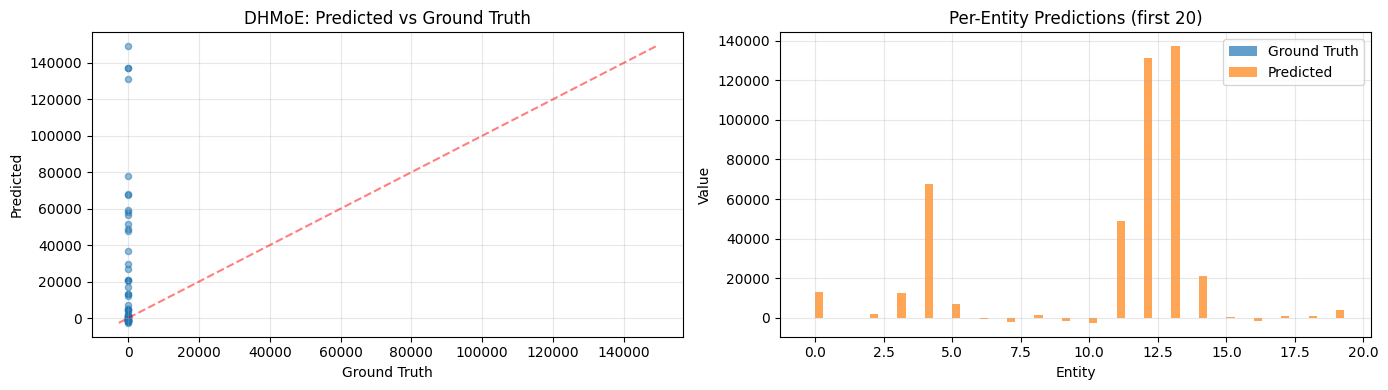

In [35]:
import matplotlib.pyplot as plt

gt = yb[0].cpu().numpy()
pred = R[0].cpu().numpy()
entities = np.arange(config.num_entities)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Scatter: predicted vs ground truth
axes[0].scatter(gt, pred, alpha=0.5, s=20)
lims = [min(gt.min(), pred.min()), max(gt.max(), pred.max())]
axes[0].plot(lims, lims, 'r--', alpha=0.5)
axes[0].set_xlabel('Ground Truth')
axes[0].set_ylabel('Predicted')
axes[0].set_title('DHMoE: Predicted vs Ground Truth')
axes[0].grid(True, alpha=0.3)

# Bar: per-entity comparison (first 20)
n_show = 20
x_pos = np.arange(n_show)
axes[1].bar(x_pos - 0.15, gt[:n_show], 0.3, label='Ground Truth', alpha=0.7)
axes[1].bar(x_pos + 0.15, pred[:n_show], 0.3, label='Predicted', alpha=0.7)
axes[1].set_xlabel('Entity')
axes[1].set_ylabel('Value')
axes[1].set_title(f'Per-Entity Predictions (first {n_show})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Visualize SSAM Expert Weights

Shows which experts the SSAM selects (sparsemax produces genuinely zero weights for unused experts).

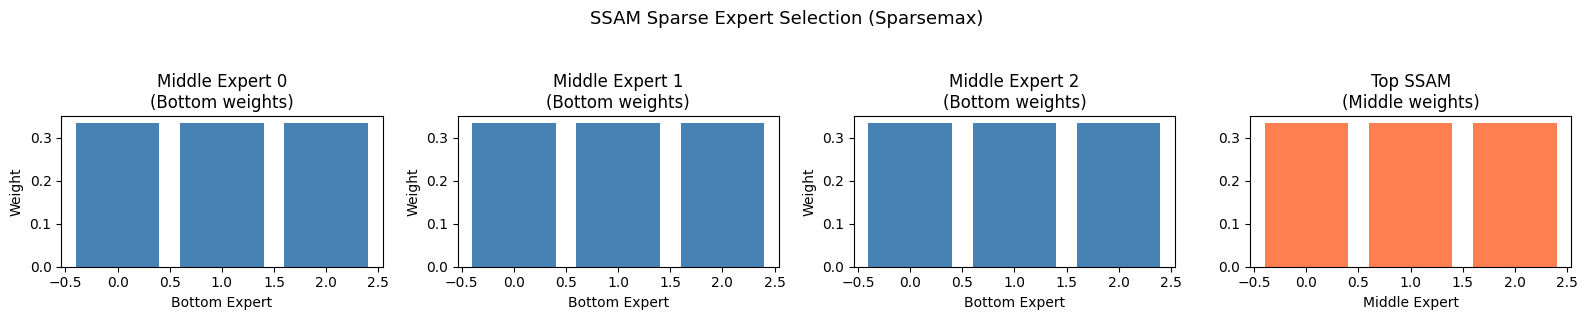

In [36]:
# Run experts to capture intermediate weights
model.eval()
with torch.no_grad():
    x_flat = xb[:1].reshape(1, config.num_entities, -1)
    E_g, E_aux = model._compute_embeddings(x_flat, A_tensors)
    k_zero = torch.zeros(1, device=device, dtype=torch.long)
    _, features = model.dit(x_flat, k_zero, E_g, E_aux)
    feat_pooled = features.mean(dim=1)

    G = [model.mlp_g[i](feat_pooled) for i in range(config.num_middle_experts)]
    G_bottom = [model.middle_experts[i](G[i]) for i in range(config.num_middle_experts)]

    modal_inputs = [
        model.modal_projs[0](x_flat),
        model.modal_projs[1](E_g),
        model.modal_projs[2](E_aux),
    ]

    # Collect bottom expert outputs per middle expert
    all_bottom = []
    for i in range(config.num_middle_experts):
        modal = modal_inputs[i % config.num_modalities]
        preds = [model.bottom_expert(modal, G_bottom[i][:, j])
                 for j in range(config.num_bottom_experts)]
        all_bottom.append(torch.stack(preds, dim=1))  # (1, b, N)

    # Get SSAM weights
    middle_preds = []
    bottom_weights = []
    for i in range(config.num_middle_experts):
        O_i = all_bottom[i]
        Q = model.ssam_bottom[i].W_q(O_i)
        K = model.ssam_bottom[i].W_k(O_i)
        attn = torch.softmax(Q @ K.transpose(-1, -2) / math.sqrt(config.num_entities), dim=-1)
        w = sparsemax(attn.sum(dim=-1), dim=-1)
        bottom_weights.append(w[0].cpu().numpy())
        middle_preds.append(torch.einsum('be,ben->bn', w, O_i))

    M_stack = torch.stack(middle_preds, dim=1)
    Q_top = model.ssam_top.W_q(M_stack)
    K_top = model.ssam_top.W_k(M_stack)
    attn_top = torch.softmax(Q_top @ K_top.transpose(-1, -2) / math.sqrt(config.num_entities), dim=-1)
    top_weights = sparsemax(attn_top.sum(dim=-1), dim=-1)[0].cpu().numpy()

fig, axes = plt.subplots(1, config.num_middle_experts + 1, figsize=(4 * (config.num_middle_experts + 1), 3))

for i in range(config.num_middle_experts):
    ax = axes[i]
    w = bottom_weights[i]
    colors = ['steelblue' if v > 0 else 'lightgray' for v in w]
    ax.bar(range(len(w)), w, color=colors)
    ax.set_title(f'Middle Expert {i}\n(Bottom weights)')
    ax.set_xlabel('Bottom Expert')
    ax.set_ylabel('Weight')

ax = axes[-1]
colors = ['coral' if v > 0 else 'lightgray' for v in top_weights]
ax.bar(range(len(top_weights)), top_weights, color=colors)
ax.set_title('Top SSAM\n(Middle weights)')
ax.set_xlabel('Middle Expert')

fig.suptitle('SSAM Sparse Expert Selection (Sparsemax)', fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

## Summary

| Component | Role | Key Equation |
|---|---|---|
| **DIT** (Root) | Conditional DDPM with iTransformer — denoises time series, generates robust features | Eq. 5, 8-10 |
| **MLP$_G$** | Maps denoised features → parameter vectors for middle experts | $G_i = \text{MLP}_G(x_0^f)$ |
| **Middle Experts** | Modulate root params with own pool, distribute to bottom | $G_{i,1:b} = G_i \odot \phi_i$ (Eq. 11) |
| **Bottom Experts** | FourierMLP with *generated* weights — processes one modality each | Eq. 12 |
| **SSAM** | Sparsemax attention aggregates predictions bottom→middle→top | Eq. 13-14 |
| **SGC** | Simplified Graph Convolution for relational embedding | Eq. 7 |

**To use with real station data:**
1. Replace `generate_random_data()` — shape `(samples, N_stations, T_hours, D_features)`
2. Build adjacency matrices from station distances / correlations
3. Adjust `config.num_entities`, `num_features`, `lookback`
4. For text data (news), replace `aux_proj` with BERT embeddings (Eq. 6)